In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


In [2]:
model = tf.keras.models.load_model(
    "final_federated_model.h5",
    compile=False
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 128)                 │         238,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 238,721 (932.50 KB)

 Trainable params: 238,721 (932.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
data = np.load("client_sequences/client_2_seq.npz", mmap_mode="r")
X, y = data["X"], data["y"]

print(X.shape, y.shape)


(295246, 5, 401) (295246,)


In [5]:
from sklearn.model_selection import train_test_split

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
y_pred_prob = model.predict(X_test, verbose=0).ravel()


In [7]:
THRESHOLD = 0.4
y_pred = (y_pred_prob > THRESHOLD).astype(int)


In [8]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Final Federated Model Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"AUC      : {auc:.4f}")


Final Federated Model Performance
--------------------------------
Accuracy : 0.2960
Recall   : 0.8888
AUC      : 0.5819


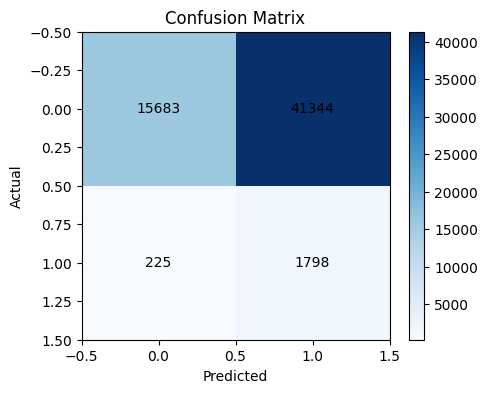

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


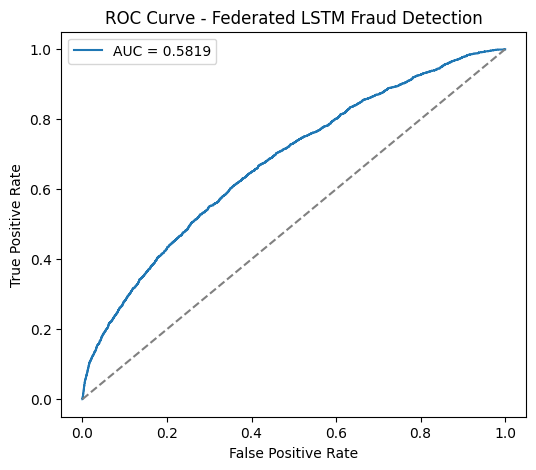

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Federated LSTM Fraud Detection")
plt.legend()
plt.show()


In [11]:
import tensorflow as tf
model = tf.keras.models.load_model("final_federated_model.h5", compile=False)
print("Model loaded successfully")


Model loaded successfully
